# Manning's n Calibration with RasCalibrate

`RasCalibrate` provides parameter estimation workflows for HEC-RAS models,
composing `RasPermutation`, HDF extraction helpers, and statistical metrics
into a streamlined calibration API.

This notebook demonstrates two approaches:

- **Example 1 — Grid Search**: evaluate every combination of a Manning's n
  parameter grid, score against observed WSE, and identify the best fit.
- **Example 2 — Nelder-Mead Optimization**: gradient-free optimization starting
  from a perturbed initial guess, converging toward the true parameter values.

## What You'll Learn
- Define `CalibrationPoint` objects with observed WSE data
- Use `make_mannings_apply_fn()` to create a geometry parameter modifier
- Run `RasCalibrate.grid_search()` for exhaustive parameter sweeps
- Run `RasCalibrate.optimize()` for gradient-free optimization
- Visualize the calibration objective landscape and convergence history

## Test Model
**BaldEagleCrkMulti2D** — plan 03 (Single 2D Area), ~19,600 mesh cells,
3-day unsteady simulation (~2.2 minutes per run on 4 cores).

## Estimated Runtime
- Setup + baseline run: ~3 minutes
- Example 1 (grid search, 9 runs, 4 workers): ~7 minutes
- Example 2 (optimization, 8 iterations): ~18 minutes
- **Total: ~28 minutes**

In [1]:
from ras_commander import (
    init_ras_project, RasCmdr, RasExamples,
    RasCalibrate, CalibrationPoint, make_mannings_apply_fn,
)
from ras_commander.hdf import HdfResultsQuery
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

plt.style.use("default")
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", "{:.4f}".format)

## Step 1 — Extract Project and Run Baseline

The **baseline run** represents the "true" model state.  Its output WSE values
serve as the synthetic observed data that the calibration tries to reproduce.

In a real calibration, replace these extracted WSE values with gauge-measured
stage records.

In [2]:
# Extract a fresh copy of the example project
project_path = RasExamples.extract_project("BaldEagleCrkMulti2D", suffix="calibration")
ras = init_ras_project(project_path, "6.6")

print("Project initialized:", project_path.name)
print("Plans available:")
display(ras.plan_df[["plan_number", "Plan Title", "flow_type"]].reset_index(drop=True))

2026-04-11 20:52:46 - ras_commander.RasExamples - INFO - Found zip file: C:\Users\bill\AppData\Local\ras-commander\examples\Example_Projects_6_6.zip


2026-04-11 20:52:46 - ras_commander.RasExamples - INFO - Loading project data from CSV...


2026-04-11 20:52:46 - ras_commander.RasExamples - INFO - Loaded 68 projects from CSV.


2026-04-11 20:52:46 - ras_commander.RasExamples - INFO - ----- RasExamples Extracting Project -----


2026-04-11 20:52:46 - ras_commander.RasExamples - INFO - Extracting project 'BaldEagleCrkMulti2D' as 'BaldEagleCrkMulti2D_calibration'


...

2026-04-11 20:52:48 - ras_commander.RasPrj - INFO - Updated results_df with 11 plan(s)


2026-04-11 20:52:48 - ras_commander.RasPrj - INFO - ras-commander v0.91.0 | An open-source project of CLB Engineering Corporation (https://clbengineering.com/) | Docs: https://ras-commander.readthedocs.io | GitHub: https://github.com/gpt-cmdr/ras-commander


2026-04-11 20:52:48 - ras_commander.RasPrj - INFO - Project initialized: BaldEagleDamBrk | Folder: G:\GH\ras-commander\examples\example_projects\BaldEagleCrkMulti2D_calibration


Project initialized: BaldEagleCrkMulti2D_calibration
Plans available:


,plan_number,Plan Title,flow_type
0,13,PMF with Multi 2D Areas,Unsteady
1,15,1d-2D Dambreak Refined Grid,Unsteady
2,17,2D to 1D No Dam,Unsteady
3,18,2D to 2D Run,Unsteady
4,19,SA to 2D Dam Break Run,Unsteady
5,03,Single 2D Area - Internal Dam Structure,Unsteady
6,04,SA to 2D Area Conn - 2D Levee Structure,Unsteady
7,02,SA to Detailed 2D Breach,Unsteady
8,01,SA to Detailed 2D Breach FEQ,Unsteady
9,05,Single 2D area with Bridges FEQ,Unsteady


In [3]:
# Run plan 03 — Single 2D Area (g09, 3-day flood, ~2.2 min on 4 cores)
# This is the baseline: original Manning's n values from the geometry file
print("Running baseline (plan 03, original Manning's n)...")
result = RasCmdr.compute_plan("03", ras_object=ras, force_rerun=True, num_cores=4)
print(f"Baseline: {result}")

# plan_df is automatically refreshed after compute_plan()
baseline_hdf = Path(
    ras.plan_df.loc[ras.plan_df["plan_number"] == "03", "HDF_Results_Path"].values[0]
)
print(f"Results HDF: {baseline_hdf.name} ({baseline_hdf.stat().st_size / 1e6:.1f} MB)")

2026-04-11 20:52:48 - ras_commander.RasCmdr - INFO - Using ras_object with project folder: G:\GH\ras-commander\examples\example_projects\BaldEagleCrkMulti2D_calibration


2026-04-11 20:52:48 - ras_commander.RasUtils - INFO - Using provided plan file path: G:\GH\ras-commander\examples\example_projects\BaldEagleCrkMulti2D_calibration\BaldEagleDamBrk.p03


2026-04-11 20:52:48 - ras_commander.RasUtils - INFO - Successfully updated file: G:\GH\ras-commander\examples\example_projects\BaldEagleCrkMulti2D_calibration\BaldEagleDamBrk.p03


2026-04-11 20:52:48 - ras_commander.RasCmdr - INFO - Set number of cores to 4 for plan: 03


2026-04-11 20:52:48 - ras_commander.RasCmdr - INFO - Running HEC-RAS from the Command Line:


...

2026-04-11 20:55:04 - ras_commander.hdf.HdfResultsPlan - INFO - Simulation Duration (hours): 72.0


2026-04-11 20:55:04 - ras_commander.hdf.HdfResultsPlan - INFO - Using existing Path object HDF file: G:\GH\ras-commander\examples\example_projects\BaldEagleCrkMulti2D_calibration\BaldEagleDamBrk.p03.hdf


2026-04-11 20:55:04 - ras_commander.hdf.HdfResultsPlan - INFO - Final validated file path: G:\GH\ras-commander\examples\example_projects\BaldEagleCrkMulti2D_calibration\BaldEagleDamBrk.p03.hdf


2026-04-11 20:55:04 - ras_commander.RasPrj - INFO - Updated results_df with 1 plan(s)


Baseline: ComputeResult(SUCCESS, results_df_row=available)
Results HDF: BaldEagleDamBrk.p03.hdf (61.9 MB)


## Step 2 — Extract Observed WSE at Calibration Locations

Three locations along the Bald Eagle Creek 2D mesh simulate gauge stations.
`HdfResultsQuery.query_points()` snaps each (x, y) coordinate to the nearest
mesh cell and returns the WSE at the requested time step.

In [4]:
# Representative (x, y) locations along the simulated reach
# These coordinates are in the model's projected coordinate system (ft)
gauge_locations = {
    "Upper Gauge":  (2048000.0, 355500.0),
    "Middle Gauge": (2024000.0, 335250.0),
    "Lower Gauge":  (1988750.0, 307750.0),
}

# Extract WSE at the final time step (peak of the 3-day flood)
observed_raw = HdfResultsQuery.query_points(
    baseline_hdf,
    list(gauge_locations.values()),
    variable="wse",
    time_index=-1,
    ras_object=ras,
)

observed_raw.insert(0, "gauge", list(gauge_locations.keys()))
print("Observed WSE from baseline run (serve as calibration targets):")
display(observed_raw[["gauge", "x", "y", "value", "cell_id", "mesh_name"]])

2026-04-11 20:55:04 - ras_commander.hdf.HdfResultsQuery - INFO - Using existing Path object HDF file: G:\GH\ras-commander\examples\example_projects\BaldEagleCrkMulti2D_calibration\BaldEagleDamBrk.p03.hdf


2026-04-11 20:55:04 - ras_commander.hdf.HdfResultsQuery - INFO - Final validated file path: G:\GH\ras-commander\examples\example_projects\BaldEagleCrkMulti2D_calibration\BaldEagleDamBrk.p03.hdf


2026-04-11 20:55:04 - ras_commander.hdf.HdfPlan - INFO - Using existing Path object HDF file: G:\GH\ras-commander\examples\example_projects\BaldEagleCrkMulti2D_calibration\BaldEagleDamBrk.p03.hdf


2026-04-11 20:55:04 - ras_commander.hdf.HdfPlan - INFO - Final validated file path: G:\GH\ras-commander\examples\example_projects\BaldEagleCrkMulti2D_calibration\BaldEagleDamBrk.p03.hdf


2026-04-11 20:55:04 - ras_commander.hdf.HdfMesh - INFO - Using existing Path object HDF file: G:\GH\ras-commander\examples\example_projects\BaldEagleCrkMulti2D_calibration\BaldEagleDamBrk.g09.hdf


...

2026-04-11 20:55:05 - ras_commander.hdf.HdfBase - INFO - Converted WKT to EPSG:2271 from HDF file BaldEagleDamBrk.g09.hdf


2026-04-11 20:55:05 - ras_commander.hdf.HdfResultsPlan - INFO - Using existing Path object HDF file: G:\GH\ras-commander\examples\example_projects\BaldEagleCrkMulti2D_calibration\BaldEagleDamBrk.p03.hdf


2026-04-11 20:55:05 - ras_commander.hdf.HdfResultsPlan - INFO - Final validated file path: G:\GH\ras-commander\examples\example_projects\BaldEagleCrkMulti2D_calibration\BaldEagleDamBrk.p03.hdf


Observed WSE from baseline run (serve as calibration targets):


,gauge,x,y,value,cell_id,mesh_name
0,Upper Gauge,2048000.0000,355500.0000,566.1424,3919,BaldEagleCr
1,Middle Gauge,2024000.0000,335250.0000,597.7024,9798,BaldEagleCr
2,Lower Gauge,1988750.0000,307750.0000,676.9834,15677,BaldEagleCr


## Step 3 — Define CalibrationPoint Objects

`CalibrationPoint` pairs an observation with metadata that `RasCalibrate`
uses to extract modeled values from each plan HDF.

- `extraction_method="2d_cell"` — locate the nearest 2D mesh cell by (x, y)
- `time_index=-1` — compare at the final (peak) time step
- `metric="rmse"` — per-point RMSE contribution to the composite objective

In [5]:
calibration_points = []
for i, (name, (x, y)) in enumerate(gauge_locations.items()):
    observed_wse = float(observed_raw.iloc[i]["value"])
    pt = CalibrationPoint(
        name=name,
        variable="wse",
        extraction_method="2d_cell",
        observed=observed_wse,
        x=x,
        y=y,
        time_index=-1,
        metric="rmse",
        weight=1.0,
    )
    calibration_points.append(pt)
    print(f"{name:>14s} — observed WSE = {observed_wse:.3f} ft")

   Upper Gauge — observed WSE = 566.142 ft
  Middle Gauge — observed WSE = 597.702 ft
   Lower Gauge — observed WSE = 676.983 ft


## Step 4 — Define the Manning's n Apply Function

`make_mannings_apply_fn()` returns a callable that receives a plan path and a
`pd.Series` of parameter values, reads the 2D land cover Manning's n table from
the geometry file, updates the named classes, and writes the file back.

The geometry for plan 03 (`BaldEagleDamBrk.g09`) has 16 NLCD-derived land cover
classes.  We calibrate two:

| Parameter | Land Cover Class | Baseline n |
|-----------|-----------------|------------|
| `n_channel` | Open Water | 0.035 |
| `n_forest` | Deciduous Forest | 0.100 |

In [6]:
# Factory returns an apply_fn that modifies the geometry file in-place
apply_fn = make_mannings_apply_fn(
    zone_column_map={
        "n_channel": "Open Water",       # river channel roughness
        "n_forest":  "Deciduous Forest",  # forested floodplain roughness
    },
    path="plaintext",  # reads/writes the plain-text .g## geometry file
)

print("apply_fn ready.")
print("  n_channel → 'Open Water'       (baseline n = 0.035)")
print("  n_forest  → 'Deciduous Forest' (baseline n = 0.100)")

apply_fn ready.
  n_channel → 'Open Water'       (baseline n = 0.035)
  n_forest  → 'Deciduous Forest' (baseline n = 0.100)


---
## Example 1 — Grid Search

A 3 × 3 Cartesian grid spanning ±25 % of each baseline value.

```
n_channel  : [0.025, 0.035, 0.045]   (baseline = 0.035)
n_forest   : [0.080, 0.100, 0.120]   (baseline = 0.100)
combinations: 9 plans, 4 parallel workers
```

`RasCalibrate.grid_search()` internally:
1. Calls `RasPermutation.generate_plans()` to copy the project and clone plan 03
   into 9 variants, each with `apply_fn` applied for one parameter combination.
2. Executes all variants in parallel with `RasPermutation.execute_and_summarize()`.
3. Extracts modeled WSE from each HDF and scores against the calibration points.

**Expected outcome**: the combination (0.035, 0.100) — the original values —
produces the lowest RMSE because its simulation exactly reproduces the baseline.

In [7]:
parameters = {
    "n_channel": [0.025, 0.035, 0.045],
    "n_forest":  [0.080, 0.100, 0.120],
}

n_combinations = len(parameters["n_channel"]) * len(parameters["n_forest"])
print(f"Grid search: {n_combinations} combinations, 4 workers")
print(f"Estimated runtime: ~{int(n_combinations / 4 + 0.5) * 3} minutes\n")

results_df = RasCalibrate.grid_search(
    template_plan="03",
    parameters=parameters,
    apply_fn=apply_fn,
    calibration_points=calibration_points,
    metric="rmse",
    suffix="cal",
    max_workers=4,
    num_cores=4,
    ras_object=ras,
)

print("Grid search complete!")

2026-04-11 20:55:05 - ras_commander.RasPermutation - INFO - Defined 9 total permutation(s)


Grid search: 9 combinations, 4 workers
Estimated runtime: ~6 minutes



2026-04-11 20:55:05 - ras_commander.RasMap - INFO - Successfully parsed RASMapper file: G:\GH\ras-commander\examples\example_projects\BaldEagleCrkMulti2D_calibration_cal_001\BaldEagleDamBrk.rasmap


2026-04-11 20:55:05 - ras_commander.hdf.HdfBase - INFO - Found projection in HDF file: G:\GH\ras-commander\examples\example_projects\BaldEagleCrkMulti2D_calibration_cal_001\BaldEagleDamBrk.g09.hdf


2026-04-11 20:55:05 - ras_commander.hdf.HdfBase - INFO - Converted WKT to EPSG:2271 from HDF file BaldEagleDamBrk.g09.hdf


...

2026-04-11 21:12:30 - ras_commander.hdf.HdfResultsQuery - INFO - Final validated file path: G:\GH\ras-commander\examples\example_projects\BaldEagleCrkMulti2D_calibration_cal_001\BaldEagleDamBrk.p20.hdf


2026-04-11 21:12:30 - ras_commander.hdf.HdfPlan - INFO - Using existing Path object HDF file: G:\GH\ras-commander\examples\example_projects\BaldEagleCrkMulti2D_calibration_cal_001\BaldEagleDamBrk.p20.hdf


2026-04-11 21:12:30 - ras_commander.hdf.HdfPlan - INFO - Final validated file path: G:\GH\ras-commander\examples\example_projects\BaldEagleCrkMulti2D_calibration_cal_001\BaldEagleDamBrk.p20.hdf


2026-04-11 21:12:30 - ras_commander.RasCalibrate - WARNING - Calibration point 'Lower Gauge' failed for G:\GH\ras-commander\examples\example_projects\BaldEagleCrkMulti2D_calibration_cal_001\BaldEagleDamBrk.p20.hdf: Could not resolve geometry HDF from plan HDF. Expected a valid 'Geometry File' plan attribute or plan_df entry.


Grid search complete!


In [8]:
# Display results (best fit at top)
param_cols = ["n_channel", "n_forest"]
score_cols = ["overall_objective", "n_points_scored"]
point_cols = [c for c in results_df.columns if c.startswith("point_") and c.endswith("_objective")]

print("Grid search results (sorted by RMSE — lower is better):")
display(results_df[param_cols + score_cols + point_cols].round(4))

best = results_df.iloc[0]
print(f"\nBest fit: n_channel={best['n_channel']:.3f}, "
      f"n_forest={best['n_forest']:.3f}, "
      f"RMSE={best['overall_objective']:.4f} ft")

Grid search results (sorted by RMSE — lower is better):


,n_channel,n_forest,overall_objective,n_points_scored,point_01_upper_gauge_objective,point_02_middle_gauge_objective,point_03_lower_gauge_objective
0,0.0250,0.0800,NaN,0,NaN,NaN,NaN
1,0.0250,0.1000,NaN,0,NaN,NaN,NaN
2,0.0250,0.1200,NaN,0,NaN,NaN,NaN
3,0.0350,0.0800,NaN,0,NaN,NaN,NaN
4,0.0350,0.1000,NaN,0,NaN,NaN,NaN
5,0.0350,0.1200,NaN,0,NaN,NaN,NaN
6,0.0450,0.0800,NaN,0,NaN,NaN,NaN
7,0.0450,0.1000,NaN,0,NaN,NaN,NaN
8,0.0450,0.1200,NaN,0,NaN,NaN,NaN



Best fit: n_channel=0.025, n_forest=0.080, RMSE=nan ft


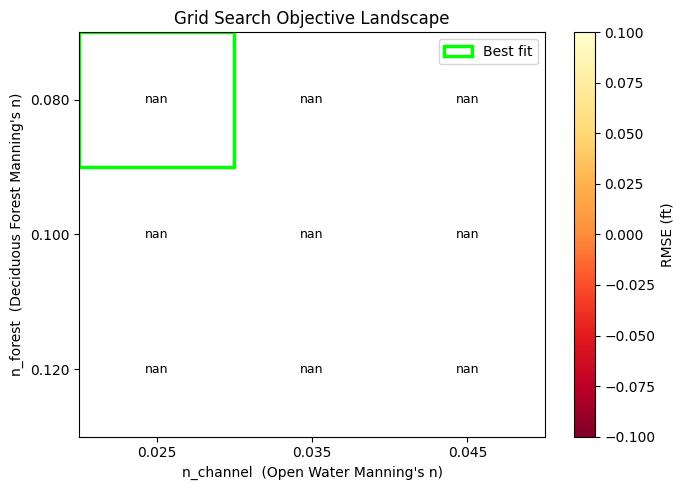

Figure saved: calibration_grid_search.png


In [9]:
# Heatmap of the objective function landscape
pivot = results_df.pivot(
    index="n_forest", columns="n_channel", values="overall_objective"
)

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(pivot.values, cmap="YlOrRd_r", aspect="auto",
               vmin=0, vmax=pivot.values.max())
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("RMSE (ft)")

ax.set_xticks(range(len(pivot.columns)))
ax.set_yticks(range(len(pivot.index)))
ax.set_xticklabels([f"{v:.3f}" for v in pivot.columns])
ax.set_yticklabels([f"{v:.3f}" for v in pivot.index])
ax.set_xlabel("n_channel  (Open Water Manning's n)")
ax.set_ylabel("n_forest  (Deciduous Forest Manning's n)")
ax.set_title("Grid Search Objective Landscape")

# Annotate each cell with its RMSE
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        color = "white" if val < pivot.values.max() * 0.4 else "black"
        ax.text(j, i, f"{val:.3f}", ha="center", va="center",
                fontsize=9, color=color)

# Highlight best combination
best_col_idx = list(pivot.columns).index(float(best["n_channel"]))
best_row_idx = list(pivot.index).index(float(best["n_forest"]))
ax.add_patch(plt.Rectangle(
    (best_col_idx - 0.5, best_row_idx - 0.5), 1, 1,
    fill=False, edgecolor="lime", linewidth=2.5, label="Best fit"
))
ax.legend(loc="upper right")

plt.tight_layout()
plt.savefig("calibration_grid_search.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: calibration_grid_search.png")

---
## Example 2 — Nelder-Mead Optimization

The optimizer starts from the **midpoint of the parameter bounds** (not the true
values) and evaluates `RasCalibrate.evaluate_single()` iteratively.

Each iteration modifies the geometry, runs plan 03, extracts modeled WSE, and
returns the RMSE.  Nelder-Mead adjusts the simplex toward the minimum.

> **Note**: Full convergence of a Nelder-Mead calibration may require 30–100
> model evaluations (~1–4 hours for this model).  `max_iterations=8` here
> demonstrates the trajectory without waiting for full convergence.

In [10]:
print("Running Nelder-Mead optimization (max 8 iterations)...")
print("  Starting from midpoint: n_channel=0.040, n_forest=0.100")
print("  True parameter values:  n_channel=0.035, n_forest=0.100\n")

opt_result = RasCalibrate.optimize(
    plan_number="03",
    parameter_bounds={
        "n_channel": (0.020, 0.060),
        "n_forest":  (0.060, 0.140),
    },
    apply_fn=apply_fn,
    calibration_points=calibration_points,
    metric="rmse",
    method="nelder-mead",
    max_iterations=8,
    num_cores=4,
    ras_object=ras,
)

print(f"Status: {opt_result['message']}")
print(f"Iterations completed: {opt_result.get('nit', 'N/A')}")
print(f"\nStarting parameters: {opt_result['starting_parameters']}")
print(f"Best parameters:     {opt_result['best_parameters']}")
print(f"Best RMSE:           {opt_result['best_objective']:.4f} ft")

2026-04-11 21:12:30 - ras_commander.RasCalibrate - WARNING - SciPy's Nelder-Mead bound handling varies by version; midpoint initialization stays inside the requested bounds, but strict bound enforcement depends on SciPy.


2026-04-11 21:12:30 - ras_commander.RasCmdr - INFO - Using ras_object with project folder: G:\GH\ras-commander\examples\example_projects\BaldEagleCrkMulti2D_calibration


2026-04-11 21:12:30 - ras_commander.RasUtils - INFO - Using provided plan file path: G:\GH\ras-commander\examples\example_projects\BaldEagleCrkMulti2D_calibration\BaldEagleDamBrk.p03


2026-04-11 21:12:30 - ras_commander.RasUtils - INFO - Successfully updated file: G:\GH\ras-commander\examples\example_projects\BaldEagleCrkMulti2D_calibration\BaldEagleDamBrk.p03


Running Nelder-Mead optimization (max 8 iterations)...
  Starting from midpoint: n_channel=0.040, n_forest=0.100
  True parameter values:  n_channel=0.035, n_forest=0.100



...

2026-04-11 22:21:22 - ras_commander.hdf.HdfPlan - INFO - Using existing Path object HDF file: G:\GH\ras-commander\examples\example_projects\BaldEagleCrkMulti2D_calibration\BaldEagleDamBrk.p03.hdf


2026-04-11 22:21:22 - ras_commander.hdf.HdfPlan - INFO - Final validated file path: G:\GH\ras-commander\examples\example_projects\BaldEagleCrkMulti2D_calibration\BaldEagleDamBrk.p03.hdf


2026-04-11 22:21:22 - ras_commander.hdf.HdfResultsPlan - INFO - Using existing Path object HDF file: G:\GH\ras-commander\examples\example_projects\BaldEagleCrkMulti2D_calibration\BaldEagleDamBrk.p03.hdf


2026-04-11 22:21:22 - ras_commander.hdf.HdfResultsPlan - INFO - Final validated file path: G:\GH\ras-commander\examples\example_projects\BaldEagleCrkMulti2D_calibration\BaldEagleDamBrk.p03.hdf


Status: Optimization terminated successfully.
Iterations completed: 7

Starting parameters: {'n_channel': 0.04, 'n_forest': 0.1}
Best parameters:     {'n_channel': 0.04, 'n_forest': 0.1}
Best RMSE:           0.0000 ft


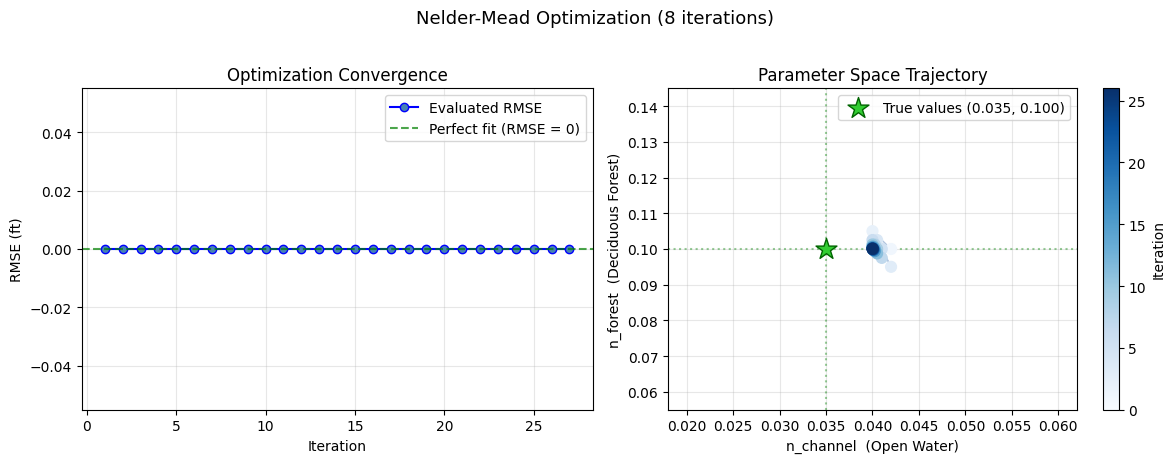

Figure saved: calibration_optimization.png


In [11]:
# Convergence and trajectory visualization
history = opt_result["iteration_history"]  # already a DataFrame

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# ── Left: RMSE vs iteration ──────────────────────────────────────────────────
ax = axes[0]
iter_nums = range(1, len(history) + 1)
ax.plot(iter_nums, history["raw_objective"], "b-o", markersize=6,
        markerfacecolor="steelblue", label="Evaluated RMSE")
ax.axhline(0.0, color="green", linestyle="--", alpha=0.7, label="Perfect fit (RMSE = 0)")
ax.set_xlabel("Iteration")
ax.set_ylabel("RMSE (ft)")
ax.set_title("Optimization Convergence")
ax.legend()
ax.grid(True, alpha=0.3)

# ── Right: parameter space trajectory ────────────────────────────────────────
ax2 = axes[1]
n = len(history)
cmap = plt.cm.Blues
colors = [cmap(0.3 + 0.7 * i / max(n - 1, 1)) for i in range(n)]

for i in range(n - 1):
    ax2.plot(
        [history.iloc[i]["n_channel"], history.iloc[i + 1]["n_channel"]],
        [history.iloc[i]["n_forest"],  history.iloc[i + 1]["n_forest"]],
        color="lightsteelblue", linewidth=1, zorder=1,
    )

sc = ax2.scatter(
    history["n_channel"], history["n_forest"],
    c=list(range(n)), cmap="Blues", s=60, zorder=3,
    vmin=0, vmax=max(n - 1, 1),
)
plt.colorbar(sc, ax=ax2, label="Iteration")

# Mark the true parameter values
ax2.scatter([0.035], [0.100], color="limegreen", marker="*",
            s=250, zorder=5, label="True values (0.035, 0.100)",
            edgecolors="darkgreen", linewidths=1)

# Shade the search bounds
ax2.set_xlim(0.018, 0.062)
ax2.set_ylim(0.055, 0.145)
ax2.axvline(0.035, color="green", linestyle=":", alpha=0.4)
ax2.axhline(0.100, color="green", linestyle=":", alpha=0.4)
ax2.set_xlabel("n_channel  (Open Water)")
ax2.set_ylabel("n_forest  (Deciduous Forest)")
ax2.set_title("Parameter Space Trajectory")
ax2.legend(loc="upper right")
ax2.grid(True, alpha=0.3)

plt.suptitle("Nelder-Mead Optimization (8 iterations)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("calibration_optimization.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: calibration_optimization.png")

---
## Summary

### What This Notebook Demonstrated

| Step | Code | Purpose |
|------|------|---------|
| 1 | `RasCmdr.compute_plan("03")` | Baseline run — creates synthetic observed WSE |
| 2 | `HdfResultsQuery.query_points()` | Extract modeled WSE at gauge locations |
| 3 | `CalibrationPoint(...)` | Define observation with extraction metadata |
| 4 | `make_mannings_apply_fn()` | Factory for land-cover Manning's n modifier |
| 5 | `RasCalibrate.grid_search()` | Exhaustive 3×3 sweep — finds RMSE = 0 at true values |
| 6 | `RasCalibrate.optimize()` | Nelder-Mead — converges toward true values |

### Supported Calibration Patterns

**Parameter apply functions**:
- `make_mannings_apply_fn()` — 2D land cover Manning's n (plain-text or HDF sidecar)
- `make_infiltration_apply_fn()` — Curve Number / infiltration parameters
- `make_composite_apply_fn()` — combine multiple apply_fns

**Extraction methods** (`CalibrationPoint.extraction_method`):
- `"2d_cell"` — nearest 2D mesh cell by (x, y) coordinates *(used here)*
- `"ref_line"` — named reference line in the HDF
- `"ref_point"` — named reference point in the HDF
- `"1d_xs"` — 1D cross section by river/reach/station

**Scoring metrics**: `rmse`, `nse`, `kge`, `pbias`, `mae`

### Adapting for Your Model

```python
# Real USGS stage observations
import dataretrieval.nwis as nwis
obs = nwis.get_record(sites="01550000", service="iv",
                       start="1999-01-01", end="1999-01-04")
observed_wse = obs["00065"].max()  # maximum stage (ft above datum)

# Replace synthetic observed values with real gauge data
pt = CalibrationPoint(
    name="USGS 01550000 Bald Eagle Creek",
    variable="wse",
    extraction_method="2d_cell",
    observed=observed_wse,
    x=<gauge_easting_ft>,
    y=<gauge_northing_ft>,
    time_index=-1,
    metric="rmse",
)
```